In [3]:
import geopandas as gpd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np

In [9]:
user = 'hubert'
file = glob.glob(f'segments/{user}/*.gpx')[0]
file

'segments/hubert/2025-09-22 184424__20250922_1844.gpx'

In [ ]:
gpx_file = open(file, 'r')
gpx = gpxpy.parse(gpx_file)


[GPXTrack(name='2025-09-22 18:44:24', description='<p>Type: Walking<br/>Start time: 18:44 Sep 22, 2025<br/>Finish time: 18:29 Sep 25, 2025<br/>Distance: 24.2 km (49:35)<br/>Moving time: 02:30<br/>Average speed: 0.49 km/h<br/>Speed in Movement: 9.63 km/h<br/>Maximum Speed: 38.37 km/h<br/>Minimum altitude: 32 m<br/>Maximum altitude: 213 m<br/>Ascent speed: 719.1 m/h<br/>Descent speed: 654.3 m/h<br/>Elevation gain: 800 m<br/>Elevation loss: 817 m<br/>Ascent time: 01:06<br/>Descent time: 01:14<br/></p><hr align="center" width="480" style="height: 2px; width: 517px"/>', segments=[GPXTrackSegment(points=[...]), GPXTrackSegment(points=[...]), GPXTrackSegment(points=[...]), GPXTrackSegment(points=[...])])]

In [143]:
def load_long_lat(user, n_segments=None):

    # Parsing an existing file:
    # -------------------------
    file = glob.glob(f'segments/{user}/*.gpx')[0]
    gpx_file = open(file, 'r')

    gpx = gpxpy.parse(gpx_file)
    track = []
    xs_tot = []
    ys_tot = []
    # xs_nc = []
    # ys_nc = []
    # cuts = []
    pts = 0
    for track_i in gpx.tracks:
        for s, segment in enumerate(track_i.segments):
            if (user == 'hubert') & (s == 1):
                continue
            if n_segments:
                if s >= n_segments:
                    return track, xs_tot, ys_tot
            xs = []
            ys = []
            for point in segment.points:
                ys.append(point.latitude)
                xs.append(point.longitude)
                # ys_tot.append(point.latitude)
                # xs_tot.append(point.longitude)
                pts += 1
                # print(f'Point at ({point.latitude},{point.longitude}) -> {point.elevation}')
            gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xs, ys), crs="EPSG:4326")
            gdf_points = gdf_points.to_crs(epsg=3857)
            xs_merc, ys_merc = zip(*[(p.x, p.y) for p in gdf_points.geometry])
            xs_merc = np.array(xs_merc)
            ys_merc = np.array(ys_merc)
            track.append({'lats': ys_merc,
                          'longs': xs_merc})
            xs_tot.extend(xs_merc)
            ys_tot.extend(ys_merc)
    return track, xs_tot, ys_tot


In [162]:
colors = {'hubert': 'cornflowerblue',
          'pa': 'tomato'}

In [ ]:
def static_plot(track, xs_tot, ys_tot, user, fig, ax,
                x_min_global, x_max_global, y_min_global, y_max_global,
                step=1):
    lw = 1
    x_min = min(xs_tot) - 500 
    x_max = max(xs_tot) + 500
    y_min = min(ys_tot) - 500 
    y_max = max(ys_tot) + 500

    if x_min_global > x_min:
        x_min_global = x_min
    if x_max_global < x_min:
        x_max_global = x_max
    if y_min_global >y_min:
        y_min_global = y_min
    if y_max_global < y_min:
        y_max_global = y_max

    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(y_min_global, y_max_global)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    
    for segment in track:
        xs = segment['longs'][::step]
        ys = segment['lats'][::step]
        ax.plot(xs, ys, color=colors[user], lw=lw, alpha=0.7)
    fig.savefig(f'{user}_until_now_{step}.png', dpi=500)
    return fig, ax

In [167]:
def plot_track(users):
    fig, ax = plt.subplots(figsize=(8,8))
    for user in users:
        track, xs_tot, ys_tot = load_long_lat(user, n_segments=None)
        fig, ax = static_plot(track, xs_tot, ys_tot, user, fig, ax, step=1)
    plt.show()


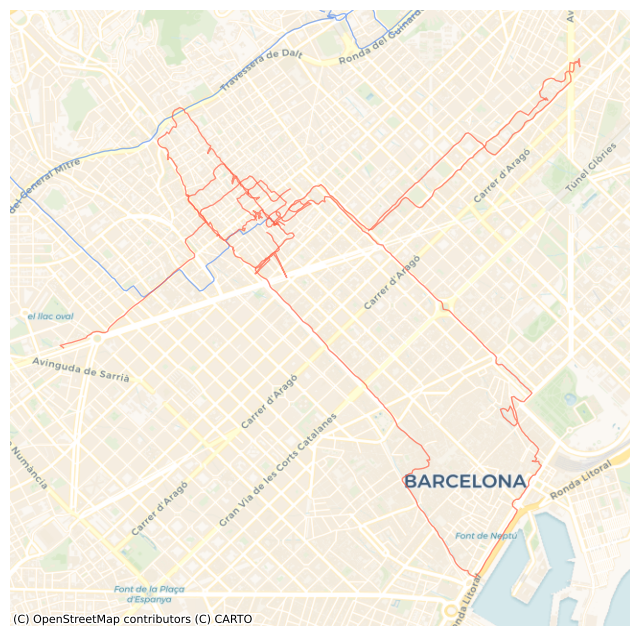

In [168]:
plot_track(['hubert', 'pa'])

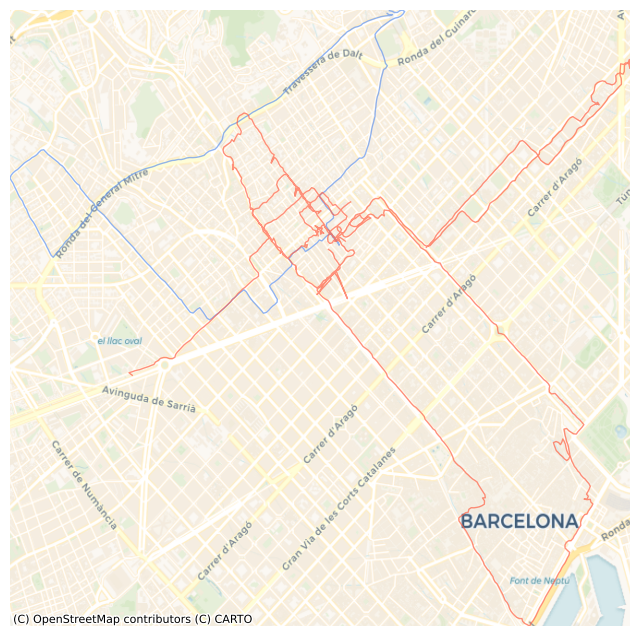

In [227]:
# Set up figure and axis
fig, ax = plt.subplots(figsize=(8,8))
step = 1
lw = 1
# Plot basemap once

ax.set_xlim(min(min(xs_hub_nc), min(xs_pa_nc)), max(max(xs_hub_nc), max(xs_pa_nc)))
ax.set_ylim(min(min(ys_hub_nc), min(ys_pa_nc)), max(max(ys_hub_nc), max(ys_pa_nc)))
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()

line_plot_hub, = ax.plot([], [], color='cornflowerblue', lw=lw, alpha=0.7)
line_plot_PA, = ax.plot([], [], color='tomato', lw=lw, alpha=0.7)  # different color

line_plot_hub.set_data(xs_hub[::step], ys_hub[::step])
line_plot_PA.set_data(xs_pa[::step], ys_pa[::step])
fig.savefig(f'untill_now_{step}.png', dpi=500)


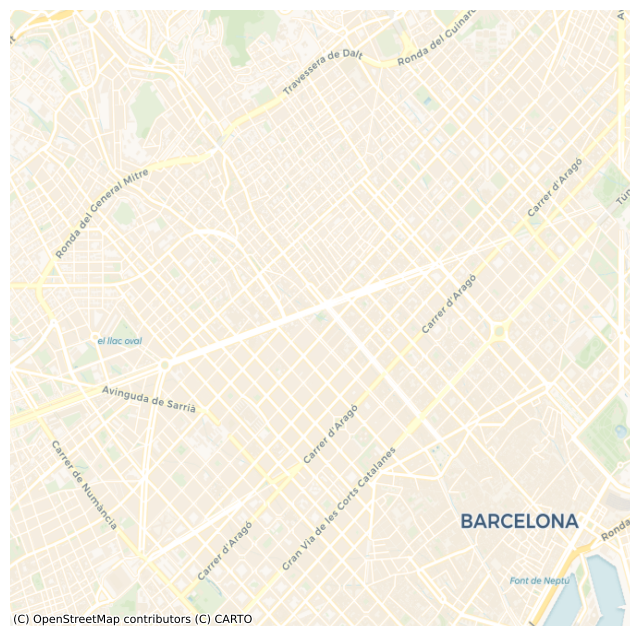

In [225]:
# Set up figure and axis
fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlim(min(min(xs_hub_nc), min(xs_pa_nc)), max(max(xs_hub_nc), max(xs_pa_nc)))
ax.set_ylim(min(min(ys_hub_nc), min(ys_pa_nc)), max(max(ys_hub_nc), max(ys_pa_nc)))
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()

xs_hub, ys_hub = deal_with_cuts(xs_hub, ys_hub)
xs_pa, ys_pa = deal_with_cuts(xs_pa, ys_pa)

lw = 1
# Create Line2D objects for both traces
line_plot_hub, = ax.plot([], [], color='cornflowerblue', lw=lw, alpha=0.7)
line_plot_PA, = ax.plot([], [], color='tomato', lw=lw, alpha=0.7)  # different color

# Initialization function
def init():
    line_plot_hub.set_data([], [])
    line_plot_PA.set_data([], [])
    return line_plot_hub, line_plot_PA

# Update function
def update(frame):
    line_plot_hub.set_data(xs_hub[:frame+1], ys_hub[:frame+1])
    line_plot_PA.set_data(xs_pa[:frame+1], ys_pa[:frame+1])
    return line_plot_hub, line_plot_PA

# Create the animation
ani = animation.FuncAnimation(
    fig, update, frames=range(0, max(len(xs_hub), len(xs_pa)), 5),
    init_func=init, blit=False, interval=50, repeat=False
)

ani.save("progressive_plot.mp4", writer="ffmpeg", fps=20)


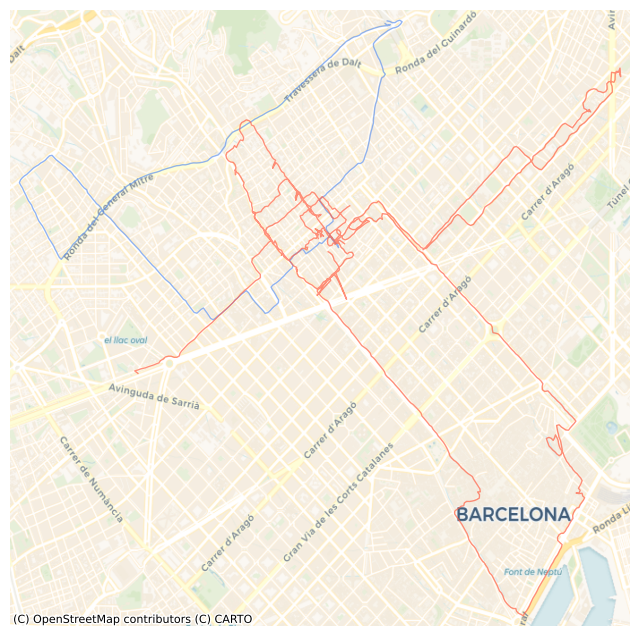

In [226]:
# Set up figure and axis
fig, ax = plt.subplots(figsize=(8,8))

# Plot basemap once
xh_for_bounds = [v for i, v in enumerate(xs_hub) if i not in cuts_hub]
yh_for_bounds = [v for i, v in enumerate(ys_hub) if i not in cuts_hub]
xpa_for_bounds = [v for i, v in enumerate(xs_pa) if i not in cuts_pa]
ypa_for_bounds = [v for i, v in enumerate(ys_pa) if i not in cuts_pa]

ax.set_xlim(min(min(xh_for_bounds), min(xpa_for_bounds))-100, max(max(xh_for_bounds), max(xpa_for_bounds))+100)
ax.set_ylim(min(min(yh_for_bounds), min(ypa_for_bounds))-100, max(max(yh_for_bounds), max(ypa_for_bounds))+100)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
ax.set_axis_off()

line_plot_hub, = ax.plot([], [], color='cornflowerblue', lw=lw, alpha=0.7)
line_plot_PA, = ax.plot([], [], color='tomato', lw=lw, alpha=0.7)  # different color

line_plot_hub.set_data(xs_hub[::step], ys_hub[::step])
line_plot_PA.set_data(xs_pa[::step], ys_pa[::step])
fig.savefig(f'untill_now_{step}.png', dpi=500)
